<a href="https://colab.research.google.com/github/SalmaAnindhia/PemMes_25_Salma/blob/main/Tugas_JS04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('insurance.csv')

In [4]:
data.head()
data.shape
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


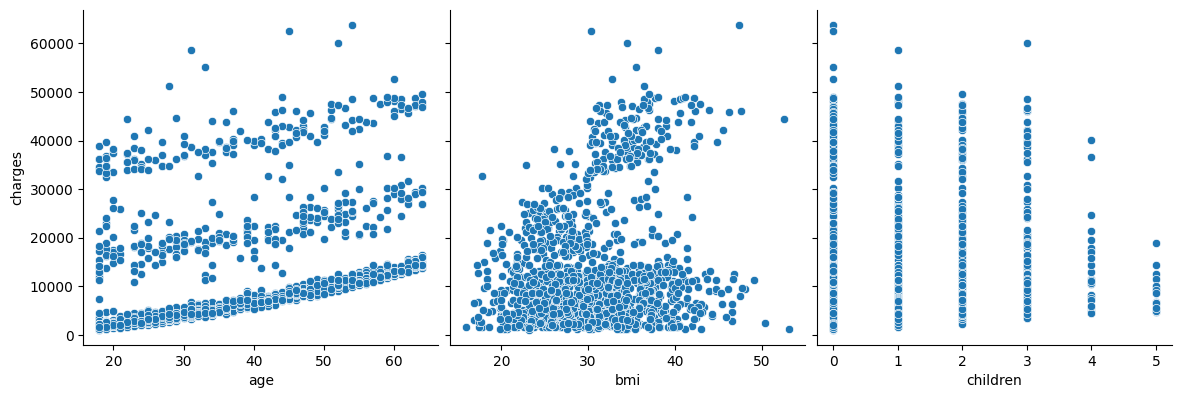

In [5]:
sns.pairplot(data, x_vars=['age', 'bmi', 'children'],
             y_vars='charges', height=4, aspect=1, kind='scatter')
plt.show()

In [6]:
data_enc = pd.get_dummies(data, drop_first=True, dtype=int)
data_enc.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


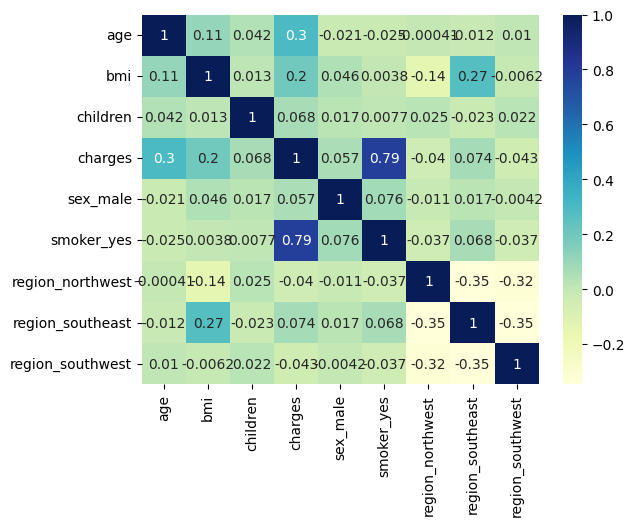

In [7]:
sns.heatmap(data_enc.corr(), cmap="YlGnBu", annot=True)
plt.show()

In [8]:
X = data_enc.drop(columns='charges')
y = data_enc['charges']

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

In [10]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("R-squared:", r2_lr)

MAE: 3943.2377039473017
MSE: 32345536.748525474
R-squared: 0.77723105117331


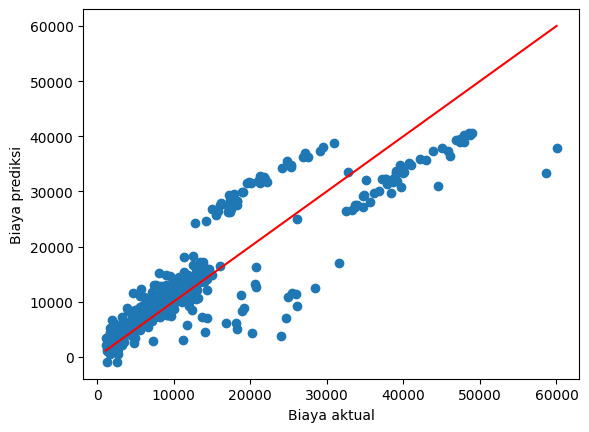

In [12]:
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r')
plt.xlabel('Biaya aktual')
plt.ylabel('Biaya prediksi')
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X_train_s = sc_X.fit_transform(X_train)
X_test_s = sc_X.transform(X_test)
y_train_s = sc_y.fit_transform(y_train.values.reshape(-1, 1))

In [14]:
from sklearn.svm import SVR
regressor = SVR(kernel='rbf')
regressor.fit(X_train_s, y_train_s)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

In [15]:
y_pred_svr = sc_y.inverse_transform(regressor.predict(X_test_s).reshape(-1, 1))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)
print("MAE:", mae_svr)
print("MSE:", mse_svr)
print("R-squared:", r2_svr)

MAE: 2410.2604402985594
MSE: 18026447.80335132
R-squared: 0.8758489352193288


In [16]:
hasil = []
for C in [1, 10, 100, 1000]:
    for gamma in [0.01, 0.1, 1]:
        reg = SVR(kernel='rbf', C=C, gamma=gamma)
        reg.fit(X_train_s, y_train_s)
        pred = sc_y.inverse_transform(reg.predict(X_test_s).reshape(-1, 1))
        hasil.append({
            'C': C,
            'gamma': gamma,
            'MAE': mean_absolute_error(y_test, pred),
            'MSE': mean_squared_error(y_test, pred),
            'R2': r2_score(y_test, pred)
        })
tabel_tuning = pd.DataFrame(hasil)
tabel_tuning

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

,C,gamma,MAE,MSE,R2
0,1,0.01,2878.698730,2.558290e+07,0.823806
1,1,0.10,2420.563946,1.806372e+07,0.875592
2,1,1.00,3774.900045,3.969811e+07,0.726593
3,10,0.01,2514.548312,1.859985e+07,0.871900
4,10,0.10,2600.522929,1.983908e+07,0.863365
5,10,1.00,4351.004574,4.521775e+07,0.688578
6,100,0.01,2520.431071,1.827945e+07,0.874106
7,100,0.10,3044.852268,2.677279e+07,0.815611
8,100,1.00,6051.862103,8.837347e+07,0.391358
9,1000,0.01,2514.474871,1.881660e+07,0.870407


In [17]:
perbandingan = pd.DataFrame({
    'Model': ['Linear Regression', 'SVR (default)'],
    'MAE': [mae_lr, mae_svr],
    'MSE': [mse_lr, mse_svr],
    'R2': [r2_lr, r2_svr]
})
perbandingan

,Model,MAE,MSE,R2
0,Linear Regression,3943.237704,3.234554e+07,0.777231
1,SVR (default),2410.260440,1.802645e+07,0.875849
